<img src="https://github.com/CharleyHananiaGA/DSB-Unit-02/blob/main/assets/ga-logo.png?raw=1" style="float: left; margin: 20px; height: 55px">

# Using `matplotlib` and `seaborn`

---

### About
Understand `matplotlib`'s object-oriented interface and create heatmaps with `seaborn`.

### Learning Objectives
- Understand the object-oriented way of working with `matplotlib` to fully control your visualizations
- Generate heat maps in `seaborn`

### Notebook Guide
- Scenario
- Different ways to use `matplotlib`
- Introducing `seaborn`
- Now You Try!
- Conclusions and Takeaways

# Scenario

You're an analyst working for CoolBricks - a new toy company who wants to compete with LEGO by producing their own bricks and sets. To better understand what kind of sets to create and at what price points, you are tasked with analyzing LEGO's catalogue over time.

The data comes from Kaggle: [https://www.kaggle.com/datasets/alexracape/lego-sets-and-prices-over-time](https://www.kaggle.com/datasets/alexracape/lego-sets-and-prices-over-time)

We are going to use `pandas` to read this data and `matplotlib` and `seaborn` to create plots.

Our research question is: ***How do product characteristics (price, number of pieces) vary across different themes and categories?***

# Different ways to use `matplotlib`
---

Part of `matplotlib`'s origin story is replicating how MATLAB creates plots. This is considered the old way of using `matplotlib` but you'll still see that code in places.

That code looks something like this:

```python
import matplotlib.pyplot as plt

plt.scatter(x=df["column_1"], y=df["column_2"])

plt.title("This is a scatter plot")
```

This is fine, but you don't have full control of your plots. The best you can do is retrieve the "most recent" plot that was created under the hood.

A better way is to use the object-oriented interface.

This means:

- Creating a blank figure (the entire chart area) and one or more axis (an individual plot)
- Using these figure and axis objects to draw your plot(s)
- Controlling every aspect of these figures and axes (titles, colors, fonts, gridlines etc.)

*Note: in `matplotlib`, every chart consists of one `Figure` and one or more `Axis` objects*

In [1]:
import pandas as pd

Let's look at the data.

In [2]:
lego_df = pd.read_csv("https://raw.githubusercontent.com/CharleyHananiaGA/DSB-Unit-02/refs/heads/main/data/lego.csv")
lego_df.head()

,Set_ID,Name,Year,Theme,Theme_Group,Subtheme,Category,Packaging,Num_Instructions,Availability,Pieces,Minifigures,Owned,Rating,USD_MSRP,Total_Quantity,Current_Price
0,75-1,PreSchool Set,1975,PreSchool,Pre-school,NaN,Normal,{Not specified},0,{Not specified},16.0,NaN,10.0,0.0,NaN,NaN,NaN
1,77-1,PreSchool Set,1975,PreSchool,Pre-school,NaN,Normal,{Not specified},0,{Not specified},20.0,NaN,11.0,0.0,NaN,NaN,NaN
2,077-1,Pre-School Set,1975,Duplo,Pre-school,NaN,Normal,{Not specified},0,{Not specified},21.0,NaN,10.0,0.0,NaN,0.0,NaN
3,78-1,PreSchool Set,1975,PreSchool,Pre-school,NaN,Normal,{Not specified},0,{Not specified},32.0,NaN,8.0,0.0,NaN,NaN,NaN
4,78-3,Basic Set,1975,Samsonite,Vintage,Basic set,Normal,Box,0,{Not specified},330.0,NaN,10.0,0.0,NaN,0.0,NaN


Let's look at the breakdown of `Category`.

In [3]:
lego_df["Category"].value_counts()

,count
Category,
Normal,12586
Gear,1232
Collection,567
Other,238
Book,142
Extended,104
Random,67


To create a bar chart, we can use the `pandas` `.plot()` function (which uses `matplotlib` under the hood)

<Axes: ylabel='Category'>

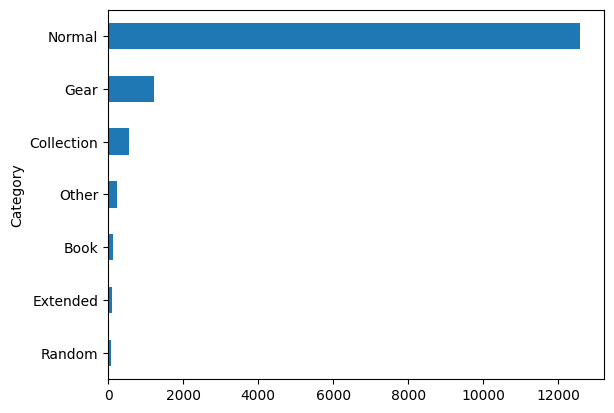

In [7]:
lego_df["Category"].value_counts().sort_values().plot(kind="barh")

We can change some options directly in `.plot()` but to have full control, we will:

- Reference `matplotlib` directly
- Create a `Figure` and `Axis` object
- Tell the `.plot()` method to use our own `Figure` and `Axis` objects rather than create its own

<class 'matplotlib.figure.Figure'>
<class 'matplotlib.axes._axes.Axes'>


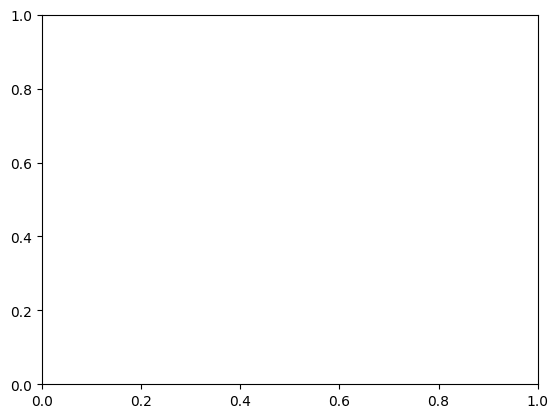

In [9]:
import matplotlib.pyplot as plt

figure, axis = plt.subplots()

print(type(figure))
print(type(axis))


[Text(0.5, 0, 'Number of products'), Text(0, 0.5, 'Product category')]

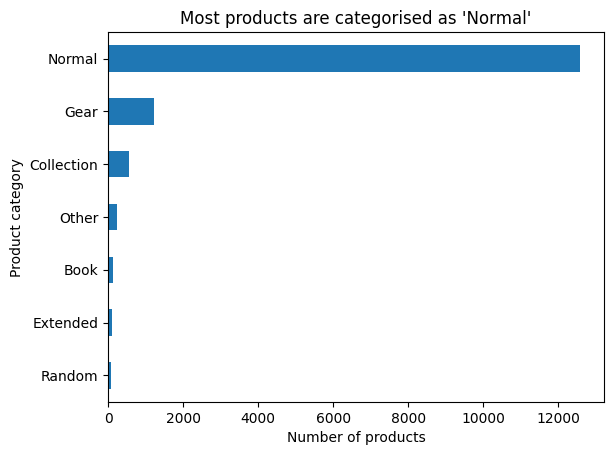

In [11]:
figure, axis = plt.subplots()

(
    lego_df["Category"].value_counts().sort_values().plot(kind="barh", ax=axis)
)

axis.set_title("Most products are categorised as 'Normal'")
axis.set(xlabel="Number of products", ylabel="Product category")

You can then even save your figure object to file!

In [12]:
figure.savefig("MyProductsChart.png")

# Introducing `seaborn`
---

Sometimes, we hit the limit of what `matplotlib` can do when we want more advanced visualizations.

One library that works much like `matplotlib` but has more advanced chart types is [`seaborn`](https://seaborn.pydata.org/).

A typical use case is creating scatter plots colored by a third variable. This is possible in `matplotlib` but much easier in `seaborn`.

In [13]:
import seaborn as sb

Seaborn also does nicer versions of box plots, histograms etc.

<Axes: xlabel='Pieces', ylabel='USD_MSRP'>

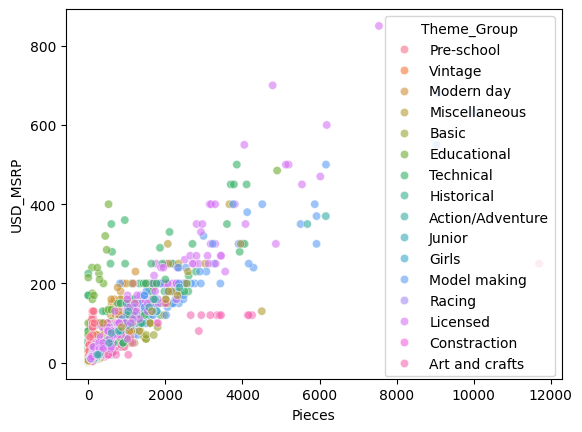

In [15]:
sb.scatterplot(
     lego_df
    ,x="Pieces"
    ,y="USD_MSRP"
    ,hue="Theme_Group"
    ,alpha=0.6

)

In [16]:
lego_df.groupby("Theme_Group")["USD_MSRP"].describe()

,count,mean,std,min,25%,50%,75%,max
Theme_Group,,,,,,,,
Action/Adventure,639.0,37.755258,36.682100,3.49,12.99,24.99,49.99,369.99
Art and crafts,86.0,32.803953,44.779069,3.99,5.99,14.99,34.99,249.99
Basic,139.0,21.241799,18.910868,2.49,7.99,14.99,29.99,99.99
Constraction,218.0,16.384541,12.442299,1.99,9.99,12.99,18.74,89.99
Educational,34.0,136.818235,115.197331,14.95,42.49,102.45,207.45,484.99
Girls,13.0,35.836154,23.968195,9.99,19.99,22.99,49.99,79.99
Historical,70.0,35.032857,32.847886,3.49,9.99,19.99,49.99,119.99
Junior,63.0,21.958254,10.142482,9.99,14.99,19.99,29.99,49.99
Licensed,1403.0,50.749095,65.750456,3.99,19.99,29.99,59.99,849.99


<Axes: xlabel='USD_MSRP', ylabel='Theme_Group'>

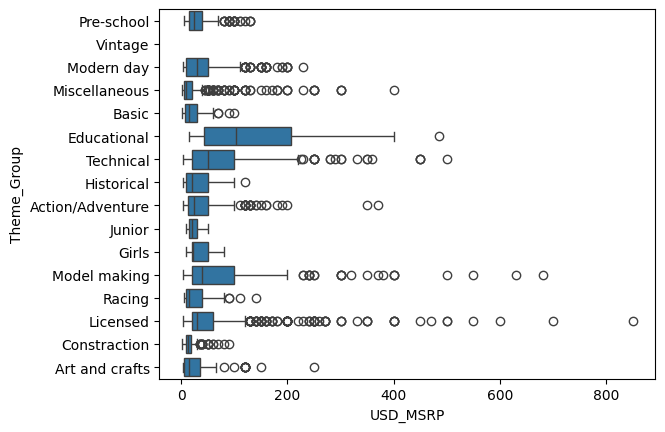

In [17]:
figure, axis = plt.subplots()
sb.boxplot(
     lego_df
    ,x="USD_MSRP"
    ,y="Theme_Group"
    ,ax=axis
)


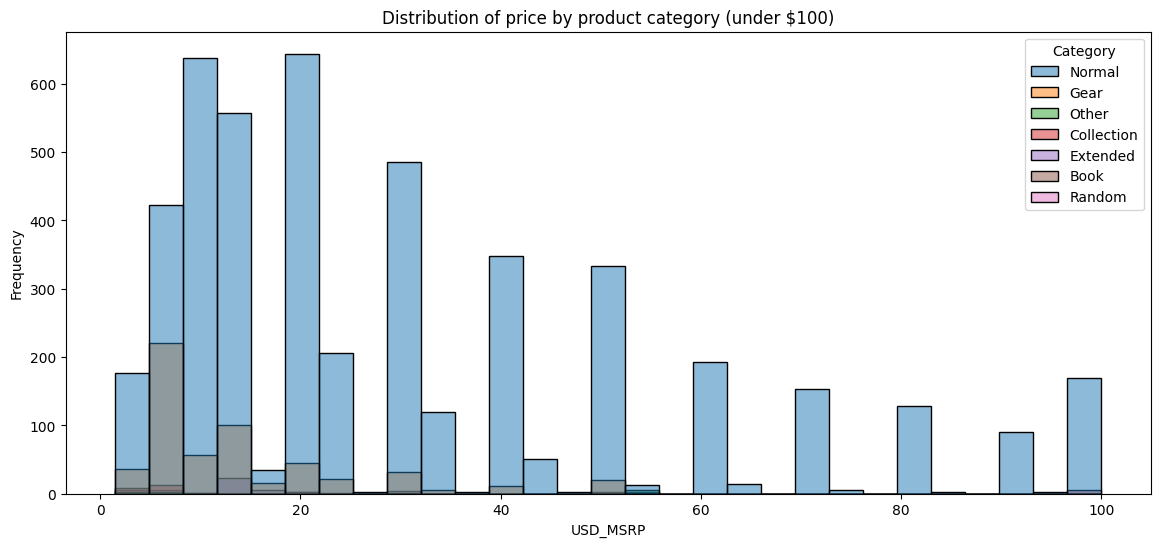

In [22]:
figure, axis = plt.subplots(figsize=(14, 6))

sb.histplot(lego_df[lego_df["USD_MSRP"] < 100], x="USD_MSRP", hue="Category", ax=axis)

axis.set(
    title="Distribution of price by product category (under $100)", ylabel="Frequency"
);

Another use case is a heatmap. Let's look at the number of products per year per category (beyond 2010 so we don't have too many columns).

In [23]:
lego_recent = lego_df[lego_df["Year"] >= 2010]

pd.crosstab(lego_recent["Category"], lego_recent["Year"])

Year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Category,,,,,,,,,,,,,,
Book,12,0,0,0,0,0,0,0,0,0,0,0,0,0
Collection,23,26,31,27,18,22,18,15,12,12,19,25,17,8
Extended,13,17,10,5,0,0,1,0,0,3,4,0,0,4
Gear,106,107,41,33,3,0,0,0,0,0,0,0,0,9
Normal,334,347,412,429,456,474,476,481,483,476,467,455,465,453
Other,9,0,0,2,19,0,0,0,0,5,6,12,9,23
Random,3,3,6,4,4,4,5,4,5,4,4,8,9,3


We can just about work out what's happening here, but `seaborn`'s heatmap lets us see patterns much more easily.

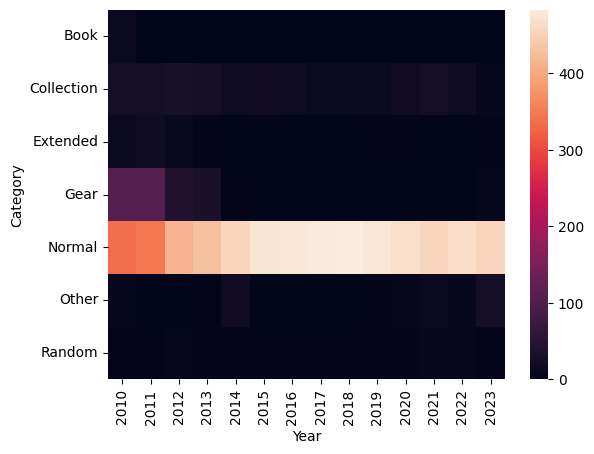

In [24]:
sb.heatmap(
    data=pd.crosstab(lego_recent["Category"], lego_recent["Year"])
);

We might want to change some of the default options:

- the colormap (the range of colors used in the scale) should be perhaps a single color from light to dark
- we can use `matplotlib` objects to control the axes, add titles etc.

*Note: read more about colormaps here: [`matplotlib` colormaps](https://matplotlib.org/stable/users/explain/colors/colormaps.html)*

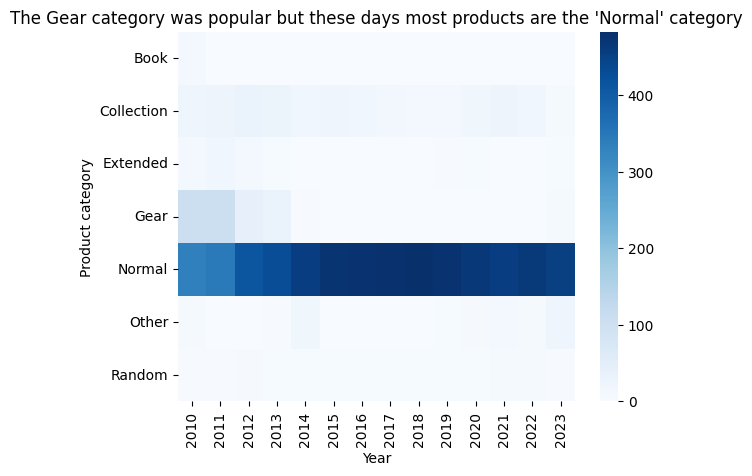

In [25]:
figure, axis = plt.subplots()

sb.heatmap(
    data=pd.crosstab(lego_recent["Category"], lego_recent["Year"]),
    cmap="Blues",
    ax=axis,
)

axis.set(
    title="The Gear category was popular but these days most products are the 'Normal' category",
    ylabel="Product category",
);

# Now You Try!
---
1. Create a crosstab to compare how many sets are in each category and theme group combinations. Have categories at the top and one row per theme group.

In [27]:
crosstab_category_theme = pd.crosstab(lego_recent["Theme_Group"], lego_recent["Category"])
crosstab_category_theme

Category,Book,Collection,Extended,Gear,Normal,Other,Random
Theme_Group,,,,,,,
Action/Adventure,0,15,6,0,649,22,0
Art and crafts,0,3,0,0,93,0,0
Basic,0,4,2,0,97,0,0
Constraction,0,15,0,0,136,0,0
Educational,0,1,0,0,148,0,0
Historical,0,0,3,0,34,0,0
Junior,0,0,0,0,67,0,0
Licensed,0,63,5,0,1635,16,9
Miscellaneous,12,93,24,299,1296,7,47


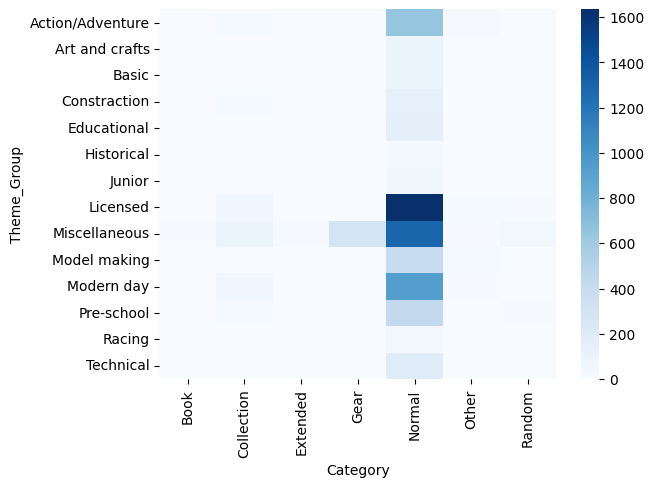

In [28]:
figure, axis = plt.subplots()

sb.heatmap(
    data=crosstab_category_theme,
    cmap="Blues",
    ax=axis,
);

2. Create a `seaborn` heatmap to visualize this information. Remember to change:

- the default color map
- the axis labels and chart title (using `matplotlib` objects)

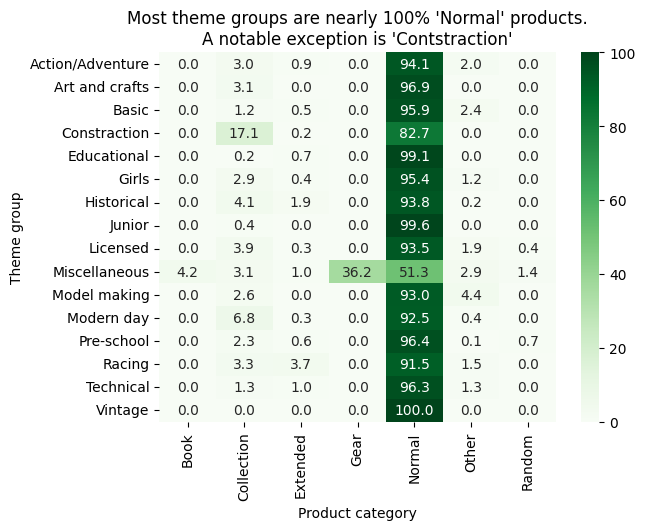

In [29]:
fig, axis = plt.subplots()

category_theme_table_normalized = (
    pd.crosstab(
        index=lego_df["Theme_Group"],
        columns=lego_df["Category"],
        normalize="index",
    )
    * 100
)

sb.heatmap(
    data=category_theme_table_normalized,
    cmap="Greens",
    vmin=0,
    vmax=100,  # numbers should go from 0-100%
    annot=True,  # add annotations
    fmt=".1f",  # show values to 1 decimal place
)

axis.set(
    title="Most theme groups are nearly 100% 'Normal' products.\nA notable exception is 'Contstraction'",
    ylabel="Theme group",
    xlabel="Product category",
);

3. *BONUS:* Work out how to change the `crosstab` to *normalize* each row, so the values represent the % of records that each product is categorized as within a theme. That is: within each theme group, what percentage of products fall in each category? Each row should add up to 100%.

Visualize this information as a heatmap.

# Conclusions and Takeaways

- The object-oriented interface is the preferred way to use `matplotlib`
- Creating `matplotlib` objects directly gives us full control over our plots
- For more advanced visualizations, `seaborn` offers a greater variety of chart types